# Data Investigation — Gold Set (CRAG) + Tracing (TBD)

**Scope.** Gold set = full CRAG dev set (`crag_task_1_and_2_dev_v4.jsonl`). Tracing data not yet available — stubbed at bottom for later.

Questions answered:
- How many queries total / per split
- What categories exist (domain, question_type, static_or_dynamic) and counts
- Answerability (idk / invalid / alt answers)
- Search-result coverage per query

In [11]:
import json
from pathlib import Path
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt

DATA_PATH = Path('../../data/raw/crag_task_1_and_2_dev_v4.jsonl')
assert DATA_PATH.exists(), DATA_PATH.resolve()

In [12]:
rows = []
with DATA_PATH.open() as f:
    for line in f:
        d = json.loads(line)
        d['n_search_results'] = len(d.get('search_results') or [])
        d['answer_str'] = str(d.get('answer') or '').strip()
        d['has_alt_ans'] = bool(d.get('alt_ans'))
        rows.append(d)

df = pd.DataFrame(rows)
df = df.drop(columns=['search_results'])  # heavy, dropped from frame
df.shape

(2706, 12)

## 1. Volume

In [13]:
print('Total queries (gold):', len(df))
print()
print('Per split:')
print(df['split'].value_counts().sort_index())

Total queries (gold): 2706

Per split:
split
0    1371
1    1335
Name: count, dtype: int64


## 2. Categories

Three category axes in CRAG: `domain`, `question_type`, `static_or_dynamic`.

In [14]:
CATS = ['domain', 'question_type', 'static_or_dynamic']
for c in CATS:
    print(f'--- {c} ({df[c].nunique()} values) ---')
    print(df[c].value_counts())
    print()

--- domain (5 values) ---
domain
finance    661
movie      611
open       542
sports     519
music      373
Name: count, dtype: int64

--- question_type (8 values) ---
question_type
simple                754
simple_w_condition    407
comparison            333
aggregation           315
false_premise         309
set                   249
multi-hop             231
post-processing       108
Name: count, dtype: int64

--- static_or_dynamic (4 values) ---
static_or_dynamic
static           1503
slow-changing     583
fast-changing     353
real-time         267
Name: count, dtype: int64



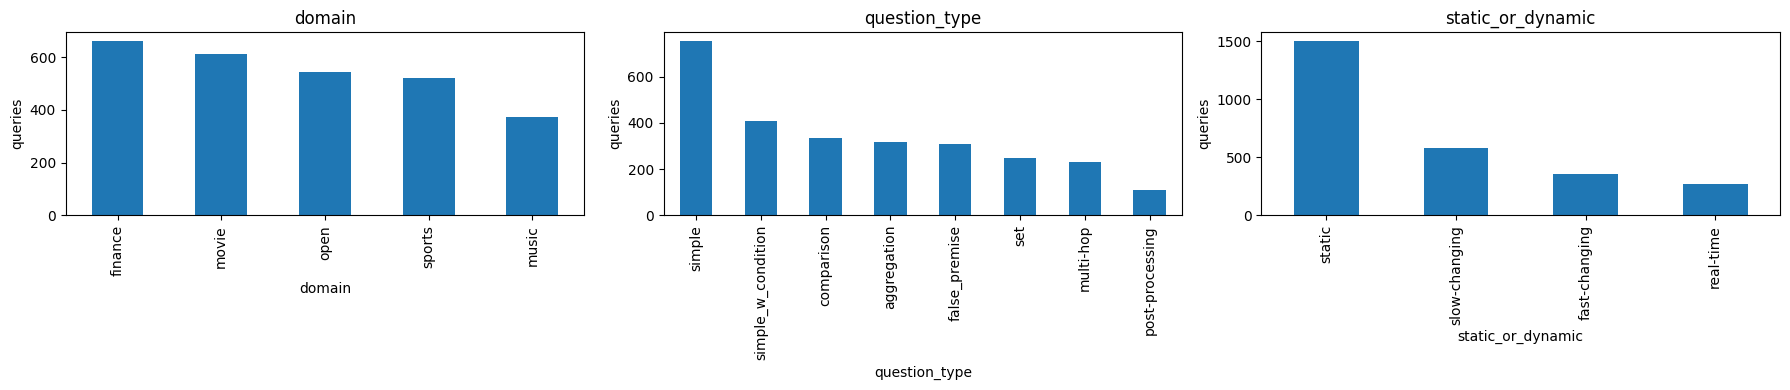

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, c in zip(axes, CATS):
    df[c].value_counts().plot.bar(ax=ax, title=c)
    ax.set_ylabel('queries')
plt.tight_layout()
plt.show()

## 3. Cross-tabs

Check whether splits are balanced across categories (stratified) and how category axes interact.

In [16]:
print('split x domain')
display(pd.crosstab(df['split'], df['domain']))
print('split x question_type')
display(pd.crosstab(df['split'], df['question_type']))
print('domain x static_or_dynamic')
display(pd.crosstab(df['domain'], df['static_or_dynamic']))

split x domain


domain,finance,movie,music,open,sports
split,,,,,
0,335,302,194,274,266
1,326,309,179,268,253


split x question_type


question_type,aggregation,comparison,false_premise,multi-hop,post-processing,set,simple,simple_w_condition
split,,,,,,,,
0,154,170,156,107,64,124,395,201
1,161,163,153,124,44,125,359,206


domain x static_or_dynamic


static_or_dynamic,fast-changing,real-time,slow-changing,static
domain,,,,
finance,134,264,107,156
movie,8,0,104,499
music,23,2,86,262
open,20,1,152,369
sports,168,0,134,217


## 4. Answerability

`idk/invalid` = ground-truth answer is "I don't know" / "invalid question" (false-premise or unanswerable). `has_alt_ans` = alternative accepted answers present.

In [17]:
IDK = {"i don't know", 'i dont know', 'invalid question'}
df['is_idk'] = df['answer_str'].str.lower().isin(IDK)
df['is_empty_ans'] = df['answer_str'].eq('')

print('empty answer   :', int(df['is_empty_ans'].sum()))
print('idk / invalid  :', int(df['is_idk'].sum()),
      f"({df['is_idk'].mean():.1%})")
print('has alt_ans    :', int(df['has_alt_ans'].sum()),
      f"({df['has_alt_ans'].mean():.1%})")
print()
print('idk rate by question_type:')
print(df.groupby('question_type')['is_idk'].mean().sort_values(ascending=False))

empty answer   : 0
idk / invalid  : 334 (12.3%)
has alt_ans    : 112 (4.1%)

idk rate by question_type:
question_type
false_premise         0.996764
simple                0.033156
simple_w_condition    0.002457
aggregation           0.000000
comparison            0.000000
multi-hop             0.000000
post-processing       0.000000
set                   0.000000
Name: is_idk, dtype: float64


## 5. Search-result coverage

Each query ships with retrieved web pages (CRAG Task 1/2 input).

In [18]:
print(df['n_search_results'].describe())
print()
print('queries with 0 search results:', int((df['n_search_results'] == 0).sum()))

count    2706.0
mean        5.0
std         0.0
min         5.0
25%         5.0
50%         5.0
75%         5.0
max         5.0
Name: n_search_results, dtype: float64

queries with 0 search results: 0


## 6. Summary

In [19]:
summary = {
    'total_queries': len(df),
    'split_0': int((df['split'] == 0).sum()),
    'split_1': int((df['split'] == 1).sum()),
    'n_domains': df['domain'].nunique(),
    'n_question_types': df['question_type'].nunique(),
    'n_dynamics': df['static_or_dynamic'].nunique(),
    'idk_or_invalid': int(df['is_idk'].sum()),
    'with_alt_ans': int(df['has_alt_ans'].sum()),
    'avg_search_results': round(df['n_search_results'].mean(), 2),
}
pd.Series(summary)

total_queries         2706.0
split_0               1371.0
split_1               1335.0
n_domains                5.0
n_question_types         8.0
n_dynamics               4.0
idk_or_invalid         334.0
with_alt_ans           112.0
avg_search_results       5.0
dtype: float64

---
## Tracing (TBD)

Tracing data not yet available. When it lands, fill the cell below and mirror the gold-set sections above (volume / categories / overlap with gold).

Open questions for tracing once available:
- How many traced queries total
- Category mix vs gold (same axes? new labels?)
- Overlap / dedup against gold `interaction_id` or `query`

In [20]:
# TRACING_PATH = Path('../../data/raw/<tracing_file>')
# TODO: load tracing data here, then repeat sections 1-6 for it
# and compare distributions against `df` (gold).
raise NotImplementedError('Tracing data not available yet')

NotImplementedError: Tracing data not available yet